# Calibration: Ranking Is Not Probability Quality

**Research question.** Does sigmoid calibration improve a reasonably calibrated random forest?

Original controlled experiment by Zangar. This notebook runs offline and uses synthetic data, never real personal records. [Source and reproduction instructions](https://github.com/zoga228/validation-stress-lab).

AI tools assisted implementation and editing; all reported measurements come from executed code.

## Experimental protocol

Use disjoint training (6000), calibration (3000), and untouched test (3000) rows. Fit the forest only on training, fit a logit-sigmoid map only on calibration, and evaluate ROC AUC, Brier score and log loss on test. A paired bootstrap estimates the uncertainty of the test Brier difference, conditional on these fitted models; it does not measure retraining uncertainty.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'
import numpy as np, pandas as pd, sklearn, matplotlib
print({'numpy':np.__version__,'pandas':pd.__version__,'sklearn':sklearn.__version__,'matplotlib':matplotlib.__version__})

{'numpy': '2.2.6', 'pandas': '2.3.1', 'sklearn': '1.7.1', 'matplotlib': '3.10.6'}


## Data-generating process

The generator is included so every assumption is inspectable. A downloadable CSV version is attached; the seeds below regenerate the same benchmark without file-path dependencies. Synthetic results illustrate a failure mode and do not establish performance on real data.

In [2]:
"""Original synthetic benchmarks; no real people, records, or competition data."""
import json
from pathlib import Path
import numpy as np
import pandas as pd


def grouped(seed=42, groups=400, repeats=30):
    rng = np.random.default_rng(seed)
    ids = np.repeat(np.arange(groups), repeats)
    latent = rng.integers(0, 2, size=groups)
    flip = rng.random(len(ids)) < .08
    return pd.DataFrame({"group_id": ids.astype(str), "sensor_noise": rng.normal(size=len(ids)), "target": np.logical_xor(latent[ids], flip).astype(int)})


def missingness(seed=42, n=6000, shifted=False):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(n, 6))
    score = 1.6*x[:, 0] - .8*x[:, 1] + .5*x[:, 2]*x[:, 3]
    y = (rng.random(n) < 1 / (1 + np.exp(-score))).astype(int)
    # An apparent signal reverses at deployment. This is a controlled stress test.
    correlated = (y + rng.normal(0, .4, n)) if not shifted else ((1-y) + rng.normal(0, .4, n))
    missing = rng.random(n) < np.where(y == 1, .3 if not shifted else .7, .1 if not shifted else .4)
    x[missing, 0] = np.nan
    df = pd.DataFrame(x, columns=[f"x{i}" for i in range(6)])
    df["spurious"] = correlated
    df["target"] = y
    return df


def regression(seed=42, n=4000, shifted=False):
    rng = np.random.default_rng(seed)
    x = rng.normal(1.8 if shifted else 0, 1, n)
    sigma = .3 + .4*np.abs(x)
    y = np.sin(2*x) + .5*x + sigma*rng.normal(size=n)
    return pd.DataFrame({"x": x, "target": y})


def export(root):
    root = Path(root)
    specs = {
        "grouped-validation": {"all.csv": grouped()},
        "missingness-shift": {"train.csv": missingness(42), "iid-test.csv": missingness(43, 3000), "shift-test.csv": missingness(44, 3000, True)},
        "conformal-shift": {"train.csv": regression(42), "calibration.csv": regression(43, 2000), "iid-test.csv": regression(44, 3000), "shift-test.csv": regression(45, 3000, True)},
    }
    for name, files in specs.items():
        folder = root / name
        folder.mkdir(parents=True, exist_ok=True)
        for filename, frame in files.items():
            frame.to_csv(folder / filename, index=False)
        info = {"synthetic": True, "license": "CC0-1.0", "generator": "make_data.py", "version": "1.0", "files": {k: {"rows": len(v), "columns": list(v)} for k, v in files.items()}, "purpose": "Controlled experiments about validation assumptions; not evidence about a real population"}
        (folder / "data-card.json").write_text(json.dumps(info, indent=2))
        print(name, info["files"])




## Fit and evaluate

Run the complete analysis. Seeds, model settings, and saved tables are explicit.

             model      auc    brier  log_loss
        raw forest 0.818034 0.173158  0.523135
sigmoid calibrated 0.818034 0.173115  0.523037
Paired test bootstrap, delta Brier (calibrated - raw), 95% CI: [-0.0002905   0.00021218]
Rows train/calibration/test: 6000 3000 3000


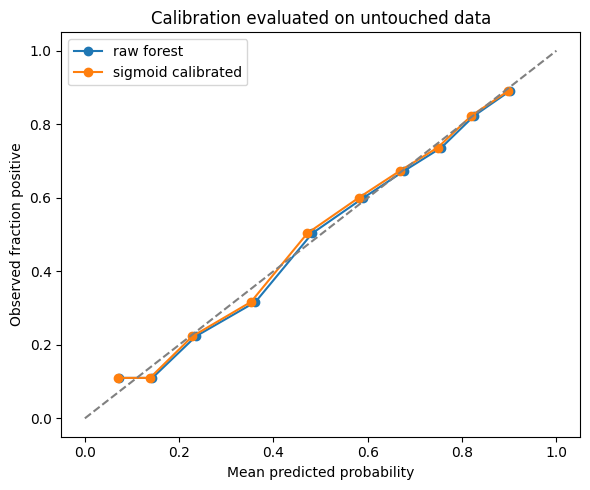

In [3]:
"""Probability calibration with untouched evaluation and paired bootstrap intervals."""
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline


def run():
    df = missingness(42, 12000)
    train, rest = train_test_split(df, test_size=.5, stratify=df.target, random_state=42)
    calibration, test = train_test_split(rest, test_size=.5, stratify=rest.target, random_state=43)
    features = [f"x{i}" for i in range(6)]
    model = make_pipeline(SimpleImputer(add_indicator=True), RandomForestClassifier(n_estimators=250, min_samples_leaf=5, max_features="sqrt", random_state=42, n_jobs=2))
    model.fit(train[features], train.target)
    def logit(p):
        p = np.clip(p, 1e-6, 1-1e-6)
        return np.log(p / (1-p)).reshape(-1, 1)
    raw_cal = model.predict_proba(calibration[features])[:, 1]
    calibrator = LogisticRegression(C=1e6).fit(logit(raw_cal), calibration.target)
    raw = model.predict_proba(test[features])[:, 1]
    calibrated = calibrator.predict_proba(logit(raw))[:, 1]
    y = test.target.to_numpy()
    metrics = pd.DataFrame([{"model": name, "auc": roc_auc_score(y, p), "brier": brier_score_loss(y, p), "log_loss": log_loss(y, p)} for name, p in (("raw forest", raw), ("sigmoid calibrated", calibrated))])
    rng = np.random.default_rng(42)
    diffs=[]
    for _ in range(1000):
        ix=rng.integers(len(y),size=len(y))
        diffs.append(np.mean((calibrated[ix]-y[ix])**2-(raw[ix]-y[ix])**2))
    interval=np.quantile(diffs,[.025,.975])
    print(metrics.to_string(index=False))
    print("Paired test bootstrap, delta Brier (calibrated - raw), 95% CI:",interval)
    print("Rows train/calibration/test:",len(train),len(calibration),len(test))
    fig,ax=plt.subplots(figsize=(6,5))
    for name,p in (("raw forest",raw),("sigmoid calibrated",calibrated)):
        true,pred=calibration_curve(y,p,n_bins=10,strategy="quantile")
        ax.plot(pred,true,"o-",label=name)
    ax.plot([0,1],[0,1],"--",color="gray")
    ax.set(xlabel="Mean predicted probability",ylabel="Observed fraction positive",title="Calibration evaluated on untouched data")
    ax.legend();fig.tight_layout()
    out=Path("outputs");out.mkdir(exist_ok=True)
    metrics.to_csv(out / "calibration.csv",index=False)
    pd.DataFrame({"low":[interval[0]],"high":[interval[1]]}).to_csv(out / "calibration-bootstrap.csv",index=False)
    fig.savefig(out / "calibration.png",dpi=160)
    plt.show()
    return metrics


results = run()

## Interpretation and limitations

The measured Brier change is small and its paired 95% bootstrap interval includes zero. There is no convincing improvement in this run. A positive-slope sigmoid preserves ranking, explaining the unchanged AUC. Calibration is an empirical question: do not claim success because a reliability diagram looks smoother. No decision threshold is tuned on the test set.

**Reference:** https://scikit-learn.org/stable/modules/calibration.html

Reproduce first, then adapt the protocol to the population and metric of your own task.